In [9]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import scipy.signal as signal
import os
import sys
import time
sys.path.append(os.path.abspath('..'))
from package import load_rirs, select_latest_rir
from package.utils import create_micsigs 
base_path = '..'
path_to_rirs = os.path.join(base_path, 'rirs')
rir_file = select_latest_rir(path_to_rirs)
acousticScenario = load_rirs(rir_file)

In [27]:
def TDOA_corr(acoustic_scenario,sound_filenames, segment_duration):
    fs = acoustic_scenario.fs
    
    peak_mic1 = np.argmax(np.abs(acoustic_scenario.RIRs_audio[:, 0, 0]))
    peak_mic2 = np.argmax(np.abs(acoustic_scenario.RIRs_audio[:, 1, 0]))
    ground_truth_tdoa = peak_mic2 - peak_mic1
      
    mics, _, _ = create_micsigs(acoustic_scenario, sound_filenames, [], duration=max(2.0,segment_duration))
    
    N = int(segment_duration * fs)
    sig1 = mics[:N, 0]
    sig2 = mics[:N, 1]

    corr = signal.correlate(sig2, sig1, mode='full')

    lags = np.arange(-N + 1, N)
    
    estimated_tdoa = lags[np.argmax(corr)]
      
    plt.figure(figsize=(10, 4))
    plt.plot(lags, corr, label='Cross-correlation function')

    plt.stem([ground_truth_tdoa], [np.max(corr)], linefmt='r--', markerfmt='ro', label='Ground Truth')
    plt.title("TDOA Schatting via Cross-correlation")
    plt.xlabel("Lag (samples)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.xlim([-50, 50])
    plt.show()
   

    print(f"Ground Truth TDOA: {ground_truth_tdoa} samples")
    print(f"Estimated TDOA:    {estimated_tdoa} samples")
    print(f"Error:             {estimated_tdoa - ground_truth_tdoa} samples")
    
    return estimated_tdoa, ground_truth_tdoa

INFO: Ruis-verwerking overgeslagen (geen bestanden of geen ruis-RIRs gevonden).


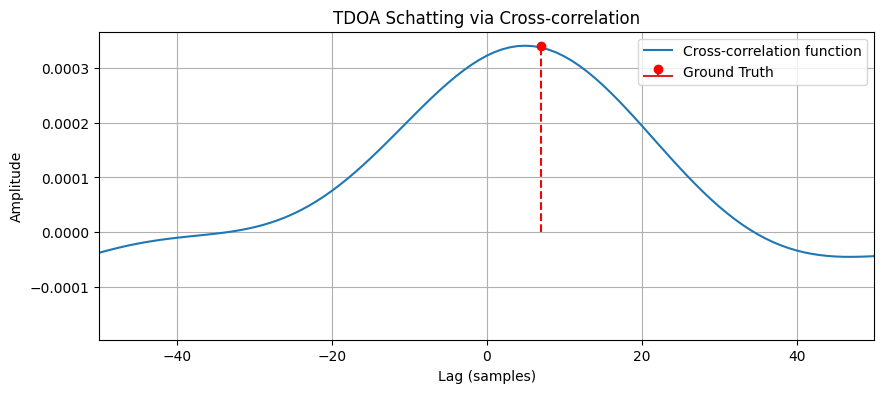

Ground Truth TDOA: 7 samples
Estimated TDOA:    5 samples
Error:             -2 samples

 De error is -2.


In [28]:
path_to_rirs = os.path.join(base_path, 'rirs')
rir_file = select_latest_rir(path_to_rirs)
acousticScenario = load_rirs(rir_file)

sound_files = [os.path.join(base_path, 'sound_files', 'part1_track1_dry.wav')]
est, gt = TDOA_corr(acousticScenario, sound_files, segment_duration=0.2)
print(f'\n De error is {est - gt}.')

In [29]:
def DOA_corr(acoustic_scenario, sound_filenames, segment_duration):
    fs = acoustic_scenario.fs
    c = acoustic_scenario.c
    pos1 = acoustic_scenario.micPos[0]
    pos2 = acoustic_scenario.micPos[1]
    d = np.sqrt(np.sum((pos1 - pos2)**2))    
    mics, _, _ = create_micsigs(acoustic_scenario, sound_filenames, [], duration=2.0)
    N = int(segment_duration * fs)
    sig1 = mics[:N, 0]
    sig2 = mics[:N, 1]
    corr = signal.correlate(sig2, sig1, mode='full') #sig1 verschuiven om op sig2 te passen
    lags = np.arange(-N + 1, N)
    estimated_tdoa = lags[np.argmax(corr)]

    tau = -estimated_tdoa / fs #samples naar sec, t1-t2, <90 eerst bij mic2 -> lag pos want sig1 moet naar rechts geschoven

    cos_theta = (tau * c) / d
    #cos_theta = np.clip(cos_theta, -1.0, 1.0) #niet buiten domein door afrondingsfouten
    theta_rad = np.arccos(cos_theta)
    theta_deg = np.degrees(theta_rad)
    DOAestAll = [theta_deg]
    print(f"Geschatte TDOA: {estimated_tdoa} samples")
    print(f"Geschatte DOA:  {theta_deg:.2f} graden")
    
    return DOAestAll

In [32]:
path_to_rirs = os.path.join(base_path, 'rirs')
rir_file = select_latest_rir(path_to_rirs)
acousticScenario = load_rirs(rir_file)

sound_files = [os.path.join(base_path, 'sound_files', 'speech1.wav')]
DOAestAll = DOA_corr(acousticScenario, sound_files, segment_duration=0.5)


INFO: Ruis-verwerking overgeslagen (geen bestanden of geen ruis-RIRs gevonden).
Geschatte TDOA: -9 samples
Geschatte DOA:  46.06 graden


INFO: Ruis-verwerking overgeslagen (geen bestanden of geen ruis-RIRs gevonden).

--- Paar Mic 1 & Mic 2 (d=0.10m, Max lag=15) ---
Geldige Piek op lag 9: DOA = 133.9 graden
Geldige Piek op lag -9: DOA = 46.1 graden


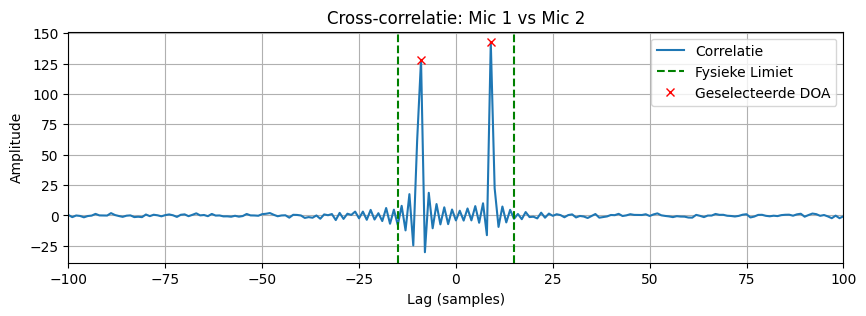


--- Paar Mic 1 & Mic 3 (d=0.20m, Max lag=28) ---
Geldige Piek op lag 18: DOA = 133.9 graden
Geldige Piek op lag -18: DOA = 46.1 graden


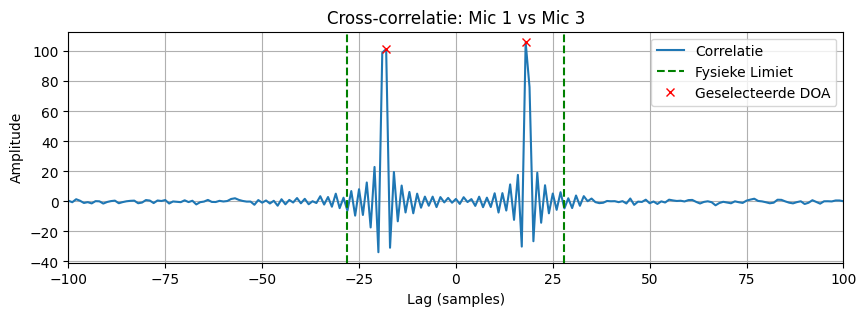


--- Paar Mic 1 & Mic 4 (d=0.30m, Max lag=41) ---
Geldige Piek op lag 28: DOA = 136.0 graden
Geldige Piek op lag -28: DOA = 44.0 graden


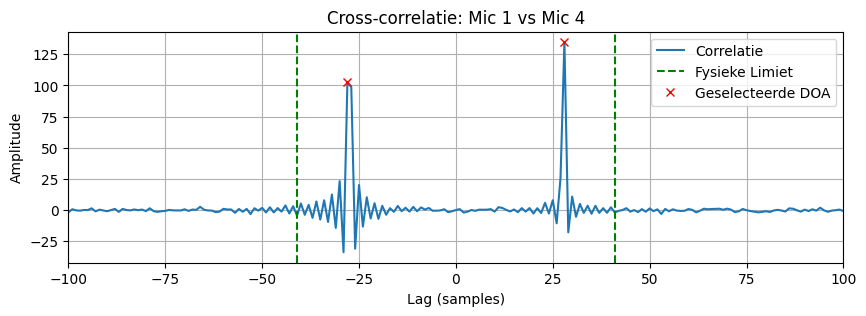


--- Paar Mic 1 & Mic 5 (d=0.40m, Max lag=54) ---
Geldige Piek op lag -36: DOA = 46.1 graden
Geldige Piek op lag 37: DOA = 135.5 graden


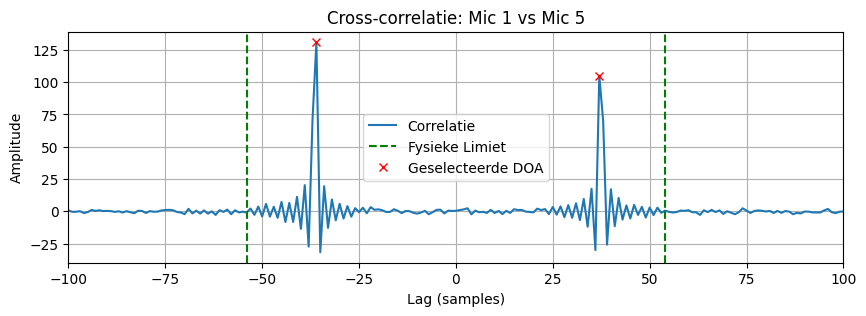


--- Paar Mic 2 & Mic 3 (d=0.10m, Max lag=15) ---
Geldige Piek op lag -9: DOA = 46.1 graden
Geldige Piek op lag 9: DOA = 133.9 graden


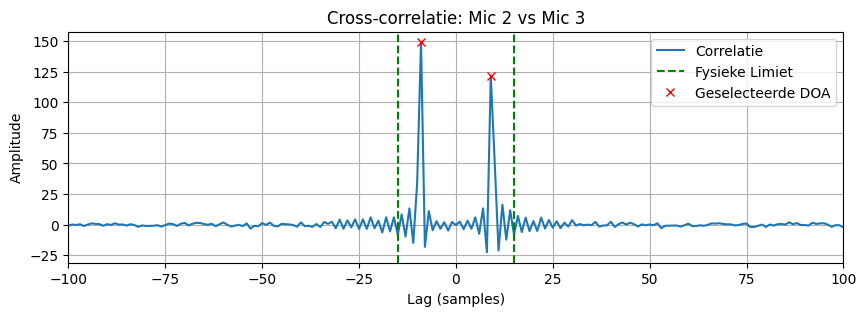


--- Paar Mic 2 & Mic 4 (d=0.20m, Max lag=28) ---
Geldige Piek op lag -18: DOA = 46.1 graden
Geldige Piek op lag 19: DOA = 137.1 graden


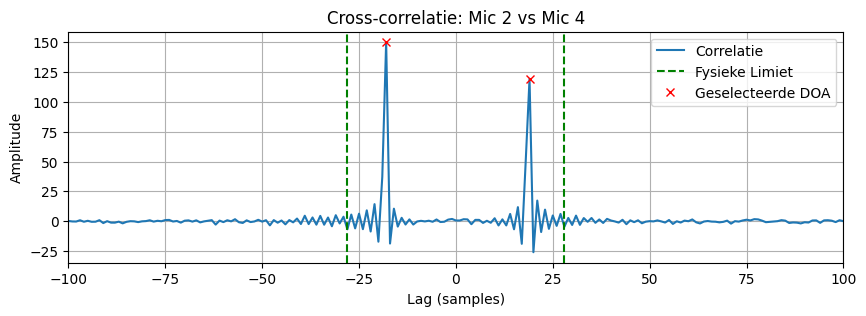


--- Paar Mic 2 & Mic 5 (d=0.30m, Max lag=41) ---
Geldige Piek op lag -27: DOA = 46.1 graden
Geldige Piek op lag 28: DOA = 136.0 graden


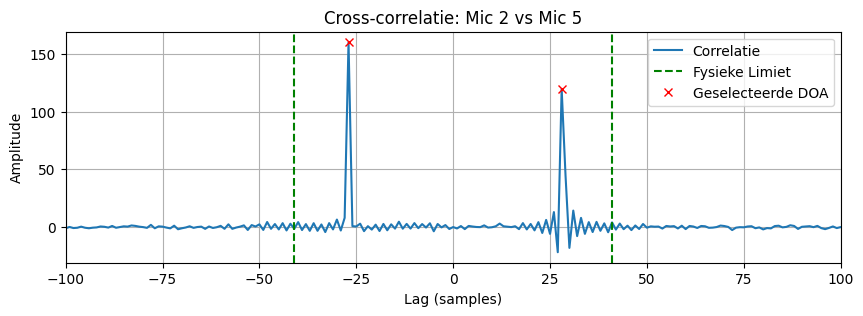


--- Paar Mic 3 & Mic 4 (d=0.10m, Max lag=15) ---
Geldige Piek op lag -9: DOA = 46.1 graden
Geldige Piek op lag 9: DOA = 133.9 graden


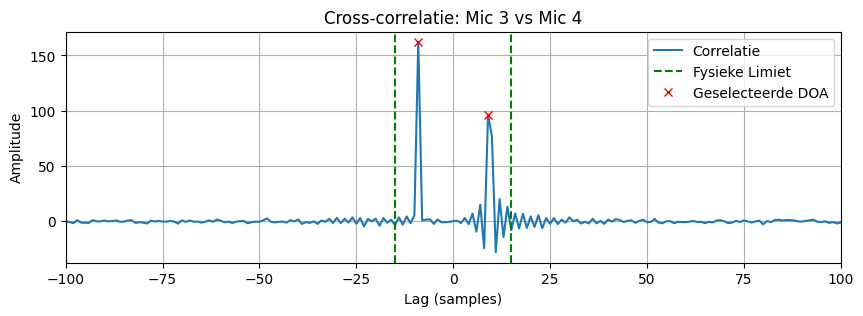


--- Paar Mic 3 & Mic 5 (d=0.20m, Max lag=28) ---
Geldige Piek op lag -18: DOA = 46.1 graden
Geldige Piek op lag 19: DOA = 137.1 graden


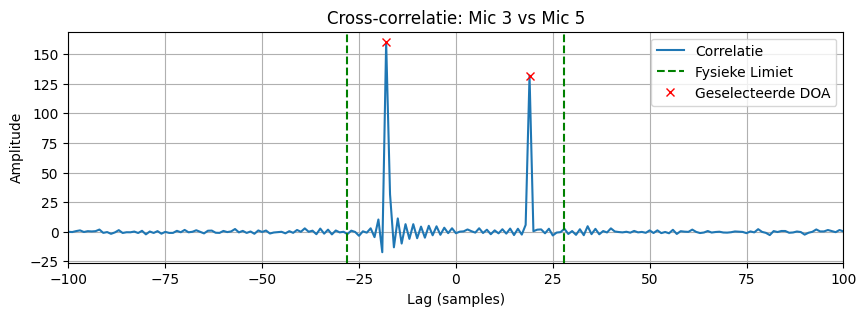


--- Paar Mic 4 & Mic 5 (d=0.10m, Max lag=15) ---
Geldige Piek op lag -9: DOA = 46.1 graden
Geldige Piek op lag 10: DOA = 140.4 graden


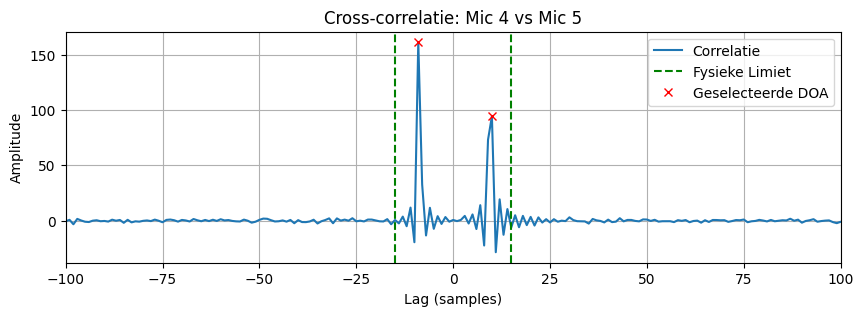

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks

all_target_files = [
    os.path.join(base_path, "sound_files", "whitenoise_signal_1.wav"),
    os.path.join(base_path, "sound_files", "whitenoise_signal_2.wav")
]

# Beperk tot het aantal bronnen dat het scenario ondersteunt
num_sources = acousticScenario.RIRs_audio.shape[2]
target_files = all_target_files[:num_sources]

mics, _, _ = create_micsigs(acousticScenario, target_files, [], duration=2.0)

fs = acousticScenario.fs
c = acousticScenario.c
num_mics = mics.shape[1]
num_sources = acousticScenario.audioPos.shape[0]

for i in range(num_mics):
    for j in range(i + 1, num_mics):
        sig_ref = mics[:, i]
        sig_comp = mics[:, j]
        corr = signal.correlate(sig_comp, sig_ref, mode='full')
        lags = signal.correlation_lags(len(sig_ref), len(sig_comp))
        pos_i = acousticScenario.micPos[i]
        pos_j = acousticScenario.micPos[j]
        d_ij = np.sqrt(np.sum((pos_i - pos_j)**2))
        max_lag_samples = int((d_ij / c) * fs) + 3
        peak_indices, _ = find_peaks(corr, height=0.1*np.max(corr), distance=5)
        sorted_peak_indices = peak_indices[np.argsort(corr[peak_indices])[::-1]]
        valid_peaks = []
        for idx in sorted_peak_indices:
            lag = lags[idx]
            if abs(lag) <= max_lag_samples:
                valid_peaks.append(idx)
            if len(valid_peaks) == num_sources:
                break
        top_peaks = valid_peaks
        print(f"\n--- Paar Mic {i+1} & Mic {j+1} (d={d_ij:.2f}m, Max lag={max_lag_samples}) ---")
        for p_idx in top_peaks:
            lag = lags[p_idx]
            tau = -lag / fs
            val = np.clip((tau * c) / d_ij, -1.0, 1.0)
            theta = np.degrees(np.arccos(val))
            print(f"Geldige Piek op lag {lag}: DOA = {theta:.1f} graden")
        plt.figure(figsize=(10, 3))
        plt.plot(lags, corr, label='Correlatie')
        plt.axvline(x=-max_lag_samples, color='g', linestyle='--', label='Fysieke Limiet')
        plt.axvline(x=max_lag_samples, color='g', linestyle='--')
        if len(top_peaks) > 0:
            plt.plot(lags[top_peaks], corr[top_peaks], "rx", label='Geselecteerde DOA')
        plt.title(f"Cross-correlatie: Mic {i+1} vs Mic {j+1}")
        plt.xlabel("Lag (samples)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.xlim([-100, 100])
        plt.show()

In [ ]:
import os
import numpy as np
import soundfile as sf
from scipy import signal
import IPython.display as ipd

base_folder = os.path.join(base_path, "sound_files", "head_mounted_rirs")
dry_signal_path = os.path.join(base_path, "sound_files", "part1_track1_dry.wav")

folder_names = ["s-90", "s-60", "s-30", "s30", "s60", "s90"]

fs_sim = 44100
c = 340
d_ear = 0.013
d_front = 0.215

dry_sig, fs_src = sf.read(dry_signal_path)

def get_doa(sig1, sig2, d, fs):
    corr = signal.correlate(sig2, sig1, mode='full')
    lags = signal.correlation_lags(len(sig1), len(sig2))
    max_lag = int((d / c) * fs) + 3
    mask = (lags >= -max_lag) & (lags <= max_lag) #alles erbinnen true, erbuiten false, geen moeilijke for lus
    if not np.any(mask): return np.nan #minstens 1 true in?
    masked_corr = corr.copy()
    masked_corr[~mask] = np.min(corr) #onmogelijke waardes krijgen minimale waarde
    peak_idx = np.argmax(masked_corr)
    lag = lags[peak_idx]
    tau = -lag / fs
    theta = np.degrees(np.arccos(np.clip((tau * c) / d, -1.0, 1.0)))
    return theta

print(f"{'Map':<10} | {'Right (1.3cm)':<15} | {'Left (1.3cm)':<15} | {'Front (21.5cm)':<15}")
print("-" * 70)

for folder in folder_names:
    path = os.path.join(base_folder, folder)
    try:
        yL1_rir, _ = sf.read(os.path.join(path, "HMIR_L1.wav"))
        yL2_rir, _ = sf.read(os.path.join(path, "HMIR_L2.wav"))
        yR1_rir, _ = sf.read(os.path.join(path, "HMIR_R1.wav"))
        yR2_rir, _ = sf.read(os.path.join(path, "HMIR_R2.wav"))
        yL1 = signal.fftconvolve(dry_sig, yL1_rir, mode='full')
        yL2 = signal.fftconvolve(dry_sig, yL2_rir, mode='full')
        yR1 = signal.fftconvolve(dry_sig, yR1_rir, mode='full')
        yR2 = signal.fftconvolve(dry_sig, yR2_rir, mode='full')
        doa_right = get_doa(yR1, yR2, d_ear, fs_sim)
        doa_left  = get_doa(yL1, yL2, d_ear, fs_sim)
        doa_front = get_doa(yL1, yR1, d_front, fs_sim)
        print(f"{folder:<10} | {doa_right:<15.1f} | {doa_left:<15.1f} | {doa_front:<15.1f}")
        if folder == "s90":
            print(f"\n--- Binauraal fragment voor {folder} ---")
            binaural = np.vstack((yL1, yR1)).T  #arrays stacken voor 2D matrix met 2 rijen
            ipd.display(ipd.Audio(binaural.T, rate=fs_sim))
            print("-" * 70)
    except Exception as e:
        print(f"Fout bij map {folder}: {e}")

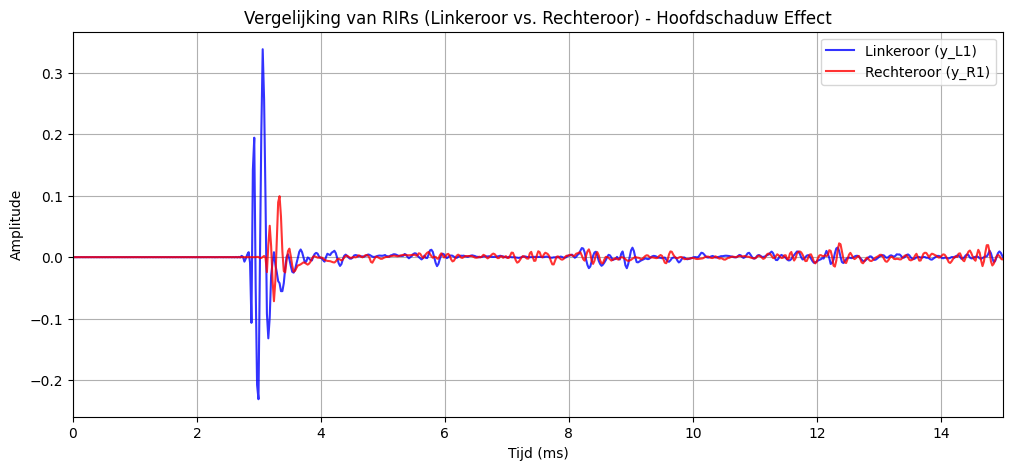

In [38]:
import os
import numpy as np
import soundfile as sf
from scipy import signal
import IPython.display as ipd
import matplotlib.pyplot as plt
base_folder = os.path.join(base_path, "sound_files", "head_mounted_rirs")
dry_signal_path = os.path.join(base_path, "sound_files", "part1_track1_dry.wav")

folder_names = ["s-90", "s-60", "s-30", "s30", "s60", "s90"]
fs_sim = 44100
c = 340
d_ear = 0.013
d_front = 0.215

dry_sig, fs_src = sf.read(dry_signal_path)

# We plotten de RIRs voor de map 's90' als voorbeeld (of pas dit aan naar een map aan de zijkant)
pad = os.path.join(base_folder, "s-30")

# RIRs inladen
rir_L1, _ = sf.read(os.path.join(pad, "HMIR_L1.wav"))
rir_R1, _ = sf.read(os.path.join(pad, "HMIR_R1.wav"))

# Plotten
plt.figure(figsize=(12, 5))

# Maak een tijds-as in milliseconden voor mooiere aflezing
t = np.arange(len(rir_L1)) / fs_sim * 1000 

plt.plot(t, rir_L1, label="Linkeroor (y_L1)", alpha=0.8, color='blue')
plt.plot(t, rir_R1, label="Rechteroor (y_R1)", alpha=0.8, color='red')

plt.title("Vergelijking van RIRs (Linkeroor vs. Rechteroor) - Hoofdschaduw Effect")
plt.xlabel("Tijd (ms)")
plt.ylabel("Amplitude")
plt.xlim([0, 15]) # Zoom in op de eerste 15 ms waar de directe paden zitten
plt.legend()
plt.grid(True)
plt.show()